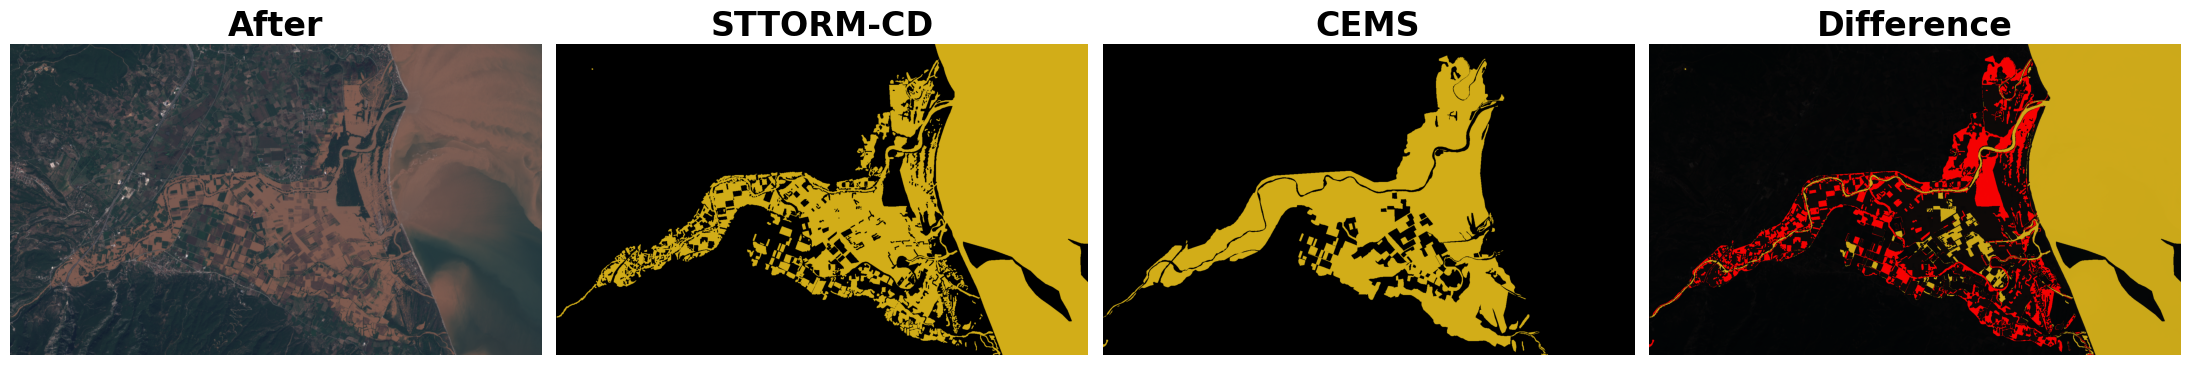

In [ ]:
import geopandas as gpd
import rasterio
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from shapely.geometry import box
from skimage.transform import resize
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

#Download AOI4 from https://mapping.emergency.copernicus.eu/activations/EMSR692/

# --- 1. PATHS ---
shapefile_path = "/Users/jonasherec/Downloads/EMSR692_AOI04_DEL_PRODUCT_v2 (1)/EMSR692_AOI04_DEL_PRODUCT_observedEventA_v2.shp"
tiff_path = "/Users/jonasherec/Downloads/2023-09-10-00_00_2023-09-10-23_59_Sentinel-2_L1C_Custom_script (1).tiff"
rgb_after_path = "/Users/jonasherec/STTORM-CD/data/dataset/train/greece_thessaly/1/rgb/2023-09-10.png"
sttorm_mask_path = "/Users/jonasherec/STTORM-CD/data/dataset/train/greece_thessaly/1/mask.png"

# Colors
YELLOW = np.array([210,173,24], dtype=np.uint8)   # STTORM / Observed color
RED    = np.array([255,0,0], dtype=np.uint8)

# --- 2. FUNCTION TO GENERATE POLYGON MASK (binary 0/1) ---
def polygon_to_mask_binary(gdf, raster_shape_hw, transform):
    from rasterio.features import rasterize
    if gdf.empty:
        return np.zeros(raster_shape_hw, dtype=np.uint8)
    mask_img = rasterize(
        [(geom, 1) for geom in gdf.geometry],
        out_shape=raster_shape_hw,
        transform=transform,
        fill=0,
        all_touched=True,
        dtype=np.uint8
    )
    return mask_img

# --- 3. LOAD & GEOREFERENCING ---
gdf = gpd.read_file(shapefile_path)

with rasterio.open(tiff_path) as src:
    tiff_data = src.read([1,2,3])
    tiff_meta = src.meta
    tiff_bounds = [float(src.bounds.left), float(src.bounds.bottom),
                   float(src.bounds.right), float(src.bounds.top)]
    raster_crs = src.crs

if gdf.crs != raster_crs:
    gdf = gdf.to_crs(raster_crs)

bbox_poly = box(*tiff_bounds)
gdf_clipped = gdf[gdf.intersects(bbox_poly)].copy()
gdf_clipped['geometry'] = gdf_clipped.geometry.intersection(bbox_poly)

# --- 4. RASTERIZE (original raster resolution, binary) ---
polygon_mask_raster = polygon_to_mask_binary(
    gdf_clipped,
    raster_shape_hw=tiff_data.shape[1:],  # H, W
    transform=tiff_meta['transform']
)

# --- 5. LOAD & RESIZE to RGB shape ---
rgb_after = np.array(Image.open(rgb_after_path))
sttorm_mask = np.array(Image.open(sttorm_mask_path))

polygon_mask = resize(
    polygon_mask_raster,
    rgb_after.shape[:2],
    order=0,
    preserve_range=True,
    anti_aliasing=False
).astype(np.uint8)

# Binarize
sttorm_bin = (np.all(sttorm_mask == [210,173,24], axis=2)).astype(np.uint8)
polygon_bin = (polygon_mask == 1).astype(np.uint8)

# --- 6. BUILD DIFFERENCE VISUALIZATION ---
h, w = polygon_bin.shape
viz = np.zeros((h, w, 3), dtype=np.uint8)  # black canva

# 2) STTORM-only (STTORM positive, polygon negative) -> YELLOW
mask_sttorm_only = (sttorm_bin == 1) & (polygon_bin == 0)
viz[mask_sttorm_only] = YELLOW

# 3) Polygon-only (polygon positive, STTORM negative) -> RED
mask_polygon_only = (polygon_bin == 1) & (sttorm_bin == 0)
viz[mask_polygon_only] = RED

# Observed Event panel (polygon pixels colored YELLOW)
observed_rgb = np.zeros((h, w, 3), dtype=np.uint8)
observed_rgb[polygon_bin == 1] = YELLOW

# --- 7. Blend overlay with RGB (safe broadcasting) ---
alpha = 0.6
# Ensure rgb has 3 channels for blending
if rgb_after.ndim == 3 and rgb_after.shape[2] == 4:
    rgb_rgb = rgb_after[..., :3].astype(np.uint8)
    alpha_chan = rgb_after[..., 3]
    need_restore_alpha = True
else:
    rgb_rgb = rgb_after.copy().astype(np.uint8)
    alpha_chan = None
    need_restore_alpha = False

overlay_mask = (viz.sum(axis=2) != 0)                # 2D boolean
overlay_mask_3ch = np.stack([overlay_mask]*3, axis=-1)

blended = rgb_rgb.astype(float).copy()
blended[overlay_mask_3ch] = (rgb_rgb[overlay_mask_3ch].astype(float)*(1-alpha) + viz[overlay_mask_3ch].astype(float)*alpha)
blended = np.clip(blended, 0, 255).astype(np.uint8)

if need_restore_alpha:
    rgb_overlay = np.dstack([blended, alpha_chan])
else:
    rgb_overlay = blended

# --- 8. PLOT ---
fig, axes = plt.subplots(1, 4, figsize=(22, 10))
title_fontsize = 24  # bigger titles

axes[0].imshow(rgb_after)
axes[0].set_title("After", fontsize=title_fontsize, fontweight='bold')

axes[1].imshow(sttorm_mask)
axes[1].set_title("STTORM-CD", fontsize=title_fontsize, fontweight='bold')

axes[2].imshow(observed_rgb)
axes[2].set_title("CEMS", fontsize=title_fontsize, fontweight='bold')

axes[3].imshow(rgb_overlay)
axes[3].imshow(viz, alpha=0.9)  # ensure colors dominate
axes[3].set_title("Difference", fontsize=title_fontsize, fontweight='bold')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.savefig("comparison.png", bbox_inches='tight', dpi=300)
plt.savefig("comparison.pdf", bbox_inches='tight', dpi=300)
plt.show(fig)

In [13]:
import math

# Tile parameters
tile_pixels = 32 * 32  # pixels per channel
channels = 10
tile_area_km2 = 0.1024  # 320x320 m = 0.1024 km²

# Total areas
europe_km2 = 6_184_800
world_km2 = 132_025_199

# Storage per representation (in bytes)
representations = {
    "Original image (Uncompressed)": 32*32*10*2,
    "Original image (1:4 compression)": (32*32*10*2)/4,
    "STTORM-CD / RaVAEn embeddings": 128*4,
    "Indices": 4
}

# Compression ratios (approx)
uncompressed_size = representations["Original image (Uncompressed)"]
compression_ratios = {name: f"1:{int(uncompressed_size / size)}" for name, size in representations.items()}

# Helper to convert bytes to kilobytes
def bytes_to_kb(n_bytes):
    return n_bytes / 1024

# Helper to floor to 2 decimal points
def floor2(x):
    return math.floor(x * 100) / 100

# Print LaTeX table
print(r"\begin{table}[h!]")
print(r"\centering")
print(r"\begin{tabular}{lcccc}")
print(r"\hline")
print(r"\textbf{Method} & \textbf{1 km²} & \makecell{\textbf{Europe (without Russia)} \\ (6,184,800\,km$^2$)} & \makecell{\textbf{World} \\ (132,025,199\,km$^2$)} & \textbf{Compression ratio} \\")
print(r"\hline")

for name, bytes_per_tile in representations.items():
    tiles_per_km2 = 1 / tile_area_km2
    storage_per_km2_kb = floor2(bytes_to_kb(bytes_per_tile * tiles_per_km2))
    europe_gb = floor2(storage_per_km2_kb * 1024 * europe_km2 / (1024**3))  # GB
    world_gb = floor2(storage_per_km2_kb * 1024 * world_km2 / (1024**3))    # GB
    print(f"{name} & {storage_per_km2_kb:,.2f} kB & {europe_gb:,.2f} GB & {world_gb:,.2f} GB & {compression_ratios[name]} \\\\")

print(r"\hline")
print(r"\end{tabular}")
print(r"\caption{Storage requirements for different representations per unit area. Computed with the world partitioned into 32x32x10 images in uint16 with 10 m GSD. The structural overhead is ignored in the computation.}")
print(r"\label{tab:compression}")
print(r"\end{table}")

\begin{table}[h!]
\centering
\begin{tabular}{lcccc}
\hline
\textbf{Method} & \textbf{1 km²} & \makecell{\textbf{Europe (without Russia)} \\ (6,184,800\,km$^2$)} & \makecell{\textbf{World} \\ (132,025,199\,km$^2$)} & \textbf{Compression ratio} \\
\hline
Original image (Uncompressed) & 195.31 kB & 1,151.99 GB & 24,591.29 GB & 1:1 \\
Original image (1:4 compression) & 48.82 kB & 287.95 GB & 6,146.87 GB & 1:4 \\
STTORM-CD / RaVAEn embeddings & 4.88 kB & 28.78 GB & 614.43 GB & 1:40 \\
Indices & 0.03 kB & 0.17 GB & 3.77 GB & 1:5120 \\
\hline
\end{tabular}
\caption{Storage requirements for different representations per unit area. Computed with the world partitioned into 32x32x10 images in uint16 with 10 m GSD. The structural overhead is ignored in the computation.}
\label{tab:compression}
\end{table}


In [59]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import rasterio
from glob import glob

# ====================== CONFIG ======================
CONFIG_STTORM_FLOODS = {
    "output_dir": "./visualizations_figures/direct_visualizations/sttorm-cd-test",
    "visualizations": [
        {
            "dataset_type": "sttorm-cd",
            "dataset": "floods_sttorm",
            "disaster_name": "germany",
            "index_label": "NDWI",
            "before_index": 2,
            "sttorm_model_best": "medium_my_variable",
            "ravaen_model_best": "medium_original",
            "pred_type": "avg",
            "layout": "narrow",
        },
        {
            "dataset_type": "sttorm-cd",
            "dataset": "floods_sttorm",
            "disaster_name": "laos",
            "index_label": "NDWI",
            "before_index": 2,
            "sttorm_model_best": "medium_my_variable",
            "ravaen_model_best": "medium_original",
            "pred_type": "avg",
            "layout": "narrow",
        },
        {
            "dataset_type": "sttorm-cd",
            "dataset": "floods_sttorm",
            "disaster_name": "niger",
            "index_label": "NDWI",
            "before_index": 1,
            "sttorm_model_best": "medium_my_variable",
            "ravaen_model_best": "medium_original",
            "pred_type": "avg",
            "layout": "narrow",
        },
        {
            "dataset_type": "sttorm-cd",
            "dataset": "floods_sttorm",
            "disaster_name": "brazil",
            "index_label": "NDWI",
            "before_index": 3,
            "sttorm_model_best": "medium_my_variable",
            "ravaen_model_best": "medium_original",
            "pred_type": "avg",
            "layout": "narrow",
        },
    ],
}

CONFIG_RAVAEN_FLOODS = {
    "output_dir": "./visualizations_figures/direct_visualizations/ravaen-floods",
    "visualizations": [
        {
            "dataset_type": "ravaen",
            "dataset": "floods",
            "disaster_name": "EMSR260_02VIADANA",
            "index_label": "NDWI",
            "before_index": 2,
            "sttorm_model_best": "small_my_variable",
            "ravaen_model_best": "small_original",
            "pred_type": "min",
            "layout": "medium",
        },
        {
            "dataset_type": "ravaen",
            "dataset": "floods",
            "disaster_name": "EMSR271_02FARKADONA",
            "index_label": "NDWI",
            "before_index": 2,
            "sttorm_model_best": "small_my_variable",
            "ravaen_model_best": "small_original",
            "pred_type": "min",
            "layout": "medium",
        },
        {
            "dataset_type": "ravaen",
            "dataset": "floods",
            "disaster_name": "EMSR324_04LESPIGNAN",
            "index_label": "NDWI",
            "before_index": 1,
            "sttorm_model_best": "small_my_variable",
            "ravaen_model_best": "small_original",
            "pred_type": "min",
            "layout": "medium",
        },
        {
            "dataset_type": "ravaen",
            "dataset": "floods",
            "disaster_name": "EMSR333_02PORTOPALO",
            "index_label": "NDWI",
            "before_index": 3,
            "sttorm_model_best": "small_my_variable",
            "ravaen_model_best": "small_original",
            "pred_type": "min",
            "layout": "medium",
        },
    ],
}

CONFIG_RAVAEN_FIRES = {
    "output_dir": "./visualizations_figures/direct_visualizations/ravaen-fires",
    "visualizations": [
        {
            "dataset_type": "ravaen",
            "dataset": "fires",
            "disaster_name": "fire_camp",
            "index_label": "NBR",
            "before_index": 2,
            "sttorm_model_best": "large_my_variable",
            "ravaen_model_best": "large_original",
            "pred_type": "min",
            "layout": "tall",
        },
        {
            "dataset_type": "ravaen",
            "dataset": "fires",
            "disaster_name": "fire_carr",
            "index_label": "NBR",
            "before_index": 2,
            "sttorm_model_best": "large_my_variable",
            "ravaen_model_best": "large_original",
            "pred_type": "min",
            "layout": "tall",
        },
        {
            "dataset_type": "ravaen",
            "dataset": "fires",
            "disaster_name": "fire_czu",
            "index_label": "NBR",
            "before_index": 1,
            "sttorm_model_best": "large_my_variable",
            "ravaen_model_best": "large_original",
            "pred_type": "min",
            "layout": "medium",
        },
        {
            "dataset_type": "ravaen",
            "dataset": "fires",
            "disaster_name": "fire_mallacoota",
            "index_label": "NBR",
            "before_index": 3,
            "sttorm_model_best": "large_my_variable",
            "ravaen_model_best": "large_original",
            "pred_type": "min",
            "layout": "medium",
        },
        {
            "dataset_type": "ravaen",
            "dataset": "fires",
            "disaster_name": "fire_riveaux",
            "index_label": "NBR",
            "before_index": 2,
            "sttorm_model_best": "large_my_variable",
            "ravaen_model_best": "large_original",
            "pred_type": "min",
            "layout": "medium",
        },
    ],
}

CONFIG_RAVAEN_LANDSLIDES = {
    "output_dir": "./visualizations_figures/direct_visualizations/ravaen-landslides",
    "visualizations": [
        {
            "dataset_type": "ravaen",
            "dataset": "landslides",
            "disaster_name": "landslide_bigsur",
            "index_label": "NDVI",
            "before_index": 2,
            "sttorm_model_best": "large_my_variable",
            "ravaen_model_best": "medium_original",
            "pred_type": "min",
            "layout": "tall",
        },
        {
            "dataset_type": "ravaen",
            "dataset": "landslides",
            "disaster_name": "landslide_fagraskogarfjall",
            "index_label": "NDVI",
            "before_index": 2,
            "sttorm_model_best": "large_my_variable",
            "ravaen_model_best": "medium_original",
            "pred_type": "min",
            "layout": "medium",
        },
        {
            "dataset_type": "ravaen",
            "dataset": "landslides",
            "disaster_name": "landslide_santalucia",
            "index_label": "NDVI",
            "before_index": 1,
            "sttorm_model_best": "large_my_variable",
            "ravaen_model_best": "medium_original",
            "pred_type": "min",
            "layout": "tall",
        },
        {
            "dataset_type": "ravaen",
            "dataset": "landslides",
            "disaster_name": "landslide_sierra",
            "index_label": "NDVI",
            "before_index": 3,
            "sttorm_model_best": "large_my_variable",
            "ravaen_model_best": "medium_original",
            "pred_type": "min",
            "layout": "medium",
        },
        {
            "dataset_type": "ravaen",
            "dataset": "landslides",
            "disaster_name": "landslide_xinmo",
            "index_label": "NDVI",
            "before_index": 2,
            "sttorm_model_best": "large_my_variable",
            "ravaen_model_best": "medium_original",
            "pred_type": "min",
            "layout": "medium",
        },
    ],
}

CONFIG_RAVAEN_HURRICANES = {
    "output_dir": "./visualizations_figures/direct_visualizations/ravaen-hurricanes",
    "visualizations": [
        {
            "dataset_type": "ravaen",
            "dataset": "hurricanes",
            "disaster_name": "hurricane_dorian_bahamas",
            "index_label": "NDVI",
            "before_index": 2,
            "sttorm_model_best": "large_my_variable",
            "ravaen_model_best": "small_original",
            "pred_type": "min",
            "layout": "tall",
        },
        {
            "dataset_type": "ravaen",
            "dataset": "hurricanes",
            "disaster_name": "hurricane_harvey_otey",
            "index_label": "NDVI",
            "before_index": 2,
            "sttorm_model_best": "large_my_variable",
            "ravaen_model_best": "small_original",
            "pred_type": "min",
            "layout": "narrow",
        },
        {
            "dataset_type": "ravaen",
            "dataset": "hurricanes",
            "disaster_name": "hurricane_irma_barbuda",
            "index_label": "NDVI",
            "before_index": 1,
            "sttorm_model_best": "large_my_variable",
            "ravaen_model_best": "small_original",
            "pred_type": "min",
            "layout": "tall",
        },
        {
            "dataset_type": "ravaen",
            "dataset": "hurricanes",
            "disaster_name": "hurricane_maria_stcroix",
            "index_label": "NDVI",
            "before_index": 3,
            "sttorm_model_best": "large_my_variable",
            "ravaen_model_best": "small_original",
            "pred_type": "min",
            "layout": "narrow",
        },
        {
            "dataset_type": "ravaen",
            "dataset": "hurricanes",
            "disaster_name": "hurricane_michael_sanblas2",
            "index_label": "NDVI",
            "before_index": 2,
            "sttorm_model_best": "large_my_variable",
            "ravaen_model_best": "small_original",
            "pred_type": "min",
            "layout": "tall",
        },
    ],
}

CONFIG=CONFIG_RAVAEN_LANDSLIDES
# =====================================================

def load_rgb_png(path):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"PNG not found: {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def highlight_compress_visualizer(
    img: np.ndarray, min_val: float = 0.0, max_val: float = 1.0
) -> np.ndarray:
    """
    Applies the HighlightCompressVisualizer piecewise function based on a knee point.
    This function compresses highlights based on a piecewise linear model where the
    transition point (the "knee") is calculated using the min and max values.
    Similar function is used for visualizations in Copernicus Browser.

    > The function hasn't been adapted precisely. The reason is that we don't have access
    to the original function source code.

    ### Important note:
    > If working with L1C products (not corrected for TOA reflectance), it is
    > recommended to preprocess the data in following way:
    > 1. Subtract offset (e.g., 1000 for Sentinel-2 L1C products).
    > 2. Divide by scale (e.g., 10000 for Sentinel-2 L1C products).
    > 3. Apply the highlight_compress_visualizer function.
    >
    > The first 2 steps are necessary to convert the data to a range suitable for visualization.
    > The original values for the individual bands offsets and the scales can be found
    > in the **'granule metadata'**: metadata file in the **GRANULE directory** for the
    > Sentinel-2 products.

    ### Links:
    * [Function description](https://docs.sentinel-hub.com/api/latest/evalscript/functions/#highlightcompressvisualizer)
    * [True color (TCI) product description](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/true_color)

    Args:
        image_data (np.ndarray): A NumPy array of data (e.g., a single-channel image).
        min_val (float): The input value mapped to 0.
        max_val (float): Controls the compression. If 0 < max_val < 1, a special
                two-stage compression is applied. Otherwise, simple linear
                scaling is performed.

    Returns:
        A NumPy array with the transformed values, mapped to the range [0, 1].
    """
    x = np.asarray(img, dtype=float)
    y = np.zeros_like(x)

    # Handle the edge case where max_value is not greater than min_val
    if max_val <= min_val:
        y[x > min_val] = 1.0
        return y

    # Case 1: Use two-stage highlight compression if 0 < max_value < 1.
    if 0 < max_val < 1:
        # The y-coordinate of the "knee" is fixed at 0.92
        knee_y = 0.92

        # Calculate the coordinates of the key points that define the function
        # Knee's X-coord: The point where the function transitions to the 2nd slope
        knee_x = min_val + knee_y * (max_val - min_val)
        # End's X-coord: The point where the output becomes 1.0
        x_end = 2 * max_val - min_val

        # Define boolean masks for each segment of the function
        mask_ramp1 = (x >= min_val) & (x <= knee_x)
        mask_ramp2 = (x > knee_x) & (x < x_end)
        mask_above = x >= x_end

        # --- Apply the calculations for each segment ---

        # Segment 1: A steep linear ramp from (minValue, 0) to (knee_x, knee_y).
        # The slope for this segment elegantly simplifies to 1 / (maxValue - minValue).
        if np.any(mask_ramp1):
            slope1 = 1.0 / (max_val - min_val)
            y[mask_ramp1] = slope1 * (x[mask_ramp1] - min_val)

        # Segment 2: A flatter linear ramp from (knee_x, knee_y) to (x_end, 1).
        if np.any(mask_ramp2):
            # Avoid division by zero if the segment has zero width
            if not np.isclose(x_end, knee_x):
                slope2 = (1.0 - knee_y) / (x_end - knee_x)
                y[mask_ramp2] = knee_y + slope2 * (x[mask_ramp2] - knee_x)
            else:  # This segment is a vertical line; clamp to 1
                y[mask_ramp2] = 1.0

        # Segment 3: All values at or above x_end are clipped to 1.
        y[mask_above] = 1.0

        # Ensure values below min_val remain 0.
        y[x < min_val] = 0.0

    # Case 2: Use simple linear scaling if max_value is outside (0, 1).
    else:
        y = (x - min_val) / (max_val - min_val)
        y = np.clip(y, 0.0, 1.0)  # Clip the results to the [0, 1] range.

    return y

def load_rgb_tif(path: str) -> np.ndarray:
    """
    Loads a TIF image as RGB using bands 4,3,2 (R,G,B) and normalizes
    it using highlight_compress_visualizer with max_val=0.5.
    
    Args:
        path (str): Path to the TIF file.
        
    Returns:
        np.ndarray: RGB image normalized to [0,1], shape (H, W, 3).
    """
    with rasterio.open(path) as src:
        # Bands: 4=R, 3=G, 2=B in 1-based indexing for rasterio
        r = src.read(4).astype(np.float32)
        g = src.read(3).astype(np.float32)
        b = src.read(2).astype(np.float32)

    # Stack as H x W x 3
    img = np.stack([r, g, b], axis=-1)/10000
    img_normalized = highlight_compress_visualizer(img,min_val=0,max_val=0.5)
    return img_normalized

def load_tif(path):
    with rasterio.open(path) as src:
        return src.read(1)

def get_disaster_index(disaster_name, folder_path):
    disasters = sorted([d for d in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, d))])
    if "ravaen" in folder_path:
        disasters = [d for d in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, d))]
    if "landslides" in folder_path:
        disasters = ["landslide_santalucia", "landslide_sierra", "landslide_fagraskogarfjall",  "landslide_bigsur", "landslide_xinmo"]
    if disaster_name not in disasters:
        raise FileNotFoundError(f"Disaster {disaster_name} not found in {folder_path}")
    return disasters.index(disaster_name)

def deduce_before_after(disaster_name, dataset_type, before_index, dataset=None):
    if dataset_type == "sttorm-cd":
        rgb_dir = f"../data/dataset/test/{disaster_name}/rgb"
        images = sorted(glob(os.path.join(rgb_dir, "*.png")))
    else:
        rgb_dir = f"../data/ravaen/{dataset}/{disaster_name}/S2"
        images = sorted(glob(os.path.join(rgb_dir, "*.tif")))
    if not images:
        raise FileNotFoundError(f"No images found in {rgb_dir}")
    after_path = images[-1]
    before_path = images[-(before_index + 1)]
    if dataset_type == "sttorm-cd":
        return load_rgb_png(before_path), load_rgb_png(after_path)
    else:
        return load_rgb_tif(before_path), load_rgb_tif(after_path)


def load_change_mask(disaster_name, dataset_type, dataset=None):
    if dataset_type == "sttorm-cd":
        mask_path = f"../data/dataset/test/{disaster_name}/mask.png"
        if os.path.exists(mask_path):
            return load_rgb_png(mask_path)
    else:
        change_dir = f"../data/ravaen/{dataset}/{disaster_name}/changes"
        masks = sorted(glob(os.path.join(change_dir, "*.tif")))
        if masks:
            return load_tif(masks[-1])
    return None

def load_model_prediction(disaster_name, model_best, pred_type, dataset=None, dataset_type=None):
    """
    Attempts to load a prediction image for any dataset type.
    The folder paths are inferred from the dataset name.
    """
    if dataset_type == "sttorm-cd":
        folder = f"./visualizations/{dataset}/{model_best}"
        disasters_folder = f"../data/dataset/test"
        idx = get_disaster_index(disaster_name, disasters_folder)
    else:  # treat as ravaen
        folder = f"./visualizations/{dataset}/{model_best}"
        disasters_folder = f"../data/ravaen/{dataset}"
        idx = get_disaster_index(disaster_name, disasters_folder)
        if "floods" == dataset:
            folder = f"./visualizations/{dataset}_ravaen/{model_best}"

    file_name = f"{idx}_{pred_type}.png"
    path = os.path.join(folder, file_name)
    if os.path.exists(path):
        return load_rgb_png(path)
    return None

def plot_visualization(entry):
    FIG_LAYOUTS = {
        "tall": {
            "figsize": (20, 10),
            "top_height": 1,
            "bottom_height": 0.85,
            "bottom_y": 0.05,
            "top_spacing": 0.04,
            "top_img_width": 0.22,
            "bottom_img_width": 0.23,
        },
        "medium": {
            "figsize": (20, 10),
            "top_height": 0.5,
            "bottom_height": 0.3,
            "bottom_y": 0.05,
            "top_spacing": 0.04,
            "top_img_width": 0.22,
            "bottom_img_width": 0.23,
        },
        "narrow": {
            "figsize": (20, 10),
            "top_height": 0.3,
            "bottom_height": 0.25,
            "bottom_y": 0.05,
            "top_spacing": 0.04,
            "top_img_width": 0.22,
            "bottom_img_width": 0.23,
        },
    }
    dataset_type = entry["dataset_type"]
    dataset = entry["dataset"]
    disaster_name = entry["disaster_name"]
    index_label = entry["index_label"]
    before_index = entry.get("before_index", 1)
    pred_type = entry.get("pred_type", "min")
    layout = entry.get("layout", "narrow")

    sttorm_model_best = entry.get("sttorm_model_best", None)
    ravaen_model_best = entry.get("ravaen_model_best", None)

    print(f"Creating visualization for {dataset_type} - {dataset} - {disaster_name}")

    # --- Top row ---
    before_img, after_img = deduce_before_after(disaster_name, dataset_type, before_index, dataset)
    change_mask = load_change_mask(disaster_name, dataset_type, dataset)

    # --- Bottom row ---
    baseline = load_model_prediction(disaster_name, "Cos_baseline", pred_type, dataset, dataset_type)
    index_img = load_model_prediction(disaster_name, "Index", pred_type, dataset, dataset_type)

    # ALWAYS attempt to load both RaVAEn and STTORM predictions
    ravaen_best = load_model_prediction(disaster_name, ravaen_model_best, pred_type, dataset, dataset_type)
    sttorm_best = load_model_prediction(disaster_name, sttorm_model_best, pred_type, dataset, dataset_type)

    # --- Plot ---
    layout = FIG_LAYOUTS[layout]

    fig = plt.figure(figsize=layout["figsize"])
    gap = 0.02
    bottom_height = layout["bottom_height"]
    top_height = layout["top_height"]
    bottom_y = layout["bottom_y"]
    top_y = bottom_y + bottom_height + gap
    top_img_width = layout["top_img_width"]
    top_spacing = layout["top_spacing"]
    bottom_img_width = layout["bottom_img_width"]
    # Top row
    top_imgs = [before_img, after_img, change_mask if change_mask is not None else np.zeros_like(before_img[:, :, 0])]
    top_titles = ["Before", "After", "Change Mask"]
    n_top = 3
    start_x = (1 - n_top * top_img_width - (n_top - 1) * top_spacing) / 2
    for i, (img, title_txt) in enumerate(zip(top_imgs, top_titles)):
        ax = fig.add_axes([start_x + i * (top_img_width + top_spacing), top_y, top_img_width, top_height])
        ax.imshow(img, cmap='gray' if i == 2 else None)
        ax.set_title(title_txt, fontsize=22, weight="bold")
        ax.axis('off')

    # Bottom row

    bottom_imgs = [baseline, index_img, ravaen_best, sttorm_best]
    bottom_titles = ["Cosine baseline", index_label, "RaVAEn - best", "STTORM-CD - best"]
    for i, (img, title_txt) in enumerate(zip(bottom_imgs, bottom_titles)):
        ax = fig.add_axes([0.05 + i*bottom_img_width, bottom_y, bottom_img_width, bottom_height])
        if img is not None:
            ax.imshow(img)
        ax.set_title(title_txt, fontsize=22, weight="bold")
        ax.axis('off')

    # Save figure
    output_dir = CONFIG["output_dir"]
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, f"{dataset_type}_{dataset}_{disaster_name}.pdf")
    plt.savefig(output_path, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved: {output_path}\n")

def main():
    for entry in CONFIG["visualizations"]:
        plot_visualization(entry)

if __name__ == "__main__":
    main()


Creating visualization for ravaen - landslides - landslide_bigsur
Saved: ./visualizations_figures/direct_visualizations/ravaen-landslides/ravaen_landslides_landslide_bigsur.pdf

Creating visualization for ravaen - landslides - landslide_fagraskogarfjall
Saved: ./visualizations_figures/direct_visualizations/ravaen-landslides/ravaen_landslides_landslide_fagraskogarfjall.pdf

Creating visualization for ravaen - landslides - landslide_santalucia
Saved: ./visualizations_figures/direct_visualizations/ravaen-landslides/ravaen_landslides_landslide_santalucia.pdf

Creating visualization for ravaen - landslides - landslide_sierra
Saved: ./visualizations_figures/direct_visualizations/ravaen-landslides/ravaen_landslides_landslide_sierra.pdf

Creating visualization for ravaen - landslides - landslide_xinmo
Saved: ./visualizations_figures/direct_visualizations/ravaen-landslides/ravaen_landslides_landslide_xinmo.pdf



In [4]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import auc
from statistics import mean
import os

# ====================== CONFIG ======================
DISASTER_CONFIG = {
    "hurricanes": {
        "index_name": "NDVI",
        "original_best": "small_original",
        "my_best": "large_my_variable",
        "recall_type": "min"
    },
    "landslides": {
        "index_name": "NDVI",
        "original_best": "medium_original",
        "my_best": "large_my_variable",
        "recall_type": "min"
    },
    "floods_ravaen": {
        "index_name": "NDWI",
        "original_best": "small_original",
        "my_best": "small_my_variable",
        "recall_type": "min"
    },
    "floods_sttorm": {
        "index_name": "NDWI",
        "original_best": "medium_original",
        "my_best": "medium_my_variable",
        "recall_type": "avg"
    },
    "fires": {
        "index_name": "NBR",
        "original_best": "large_original",
        "my_best": "large_my_variable",
        "recall_type": "min"
    },
}

BASE_PATH = "./test_metrics_logs/"

# ====================== UTILS ======================
def load_recalls_from_json(json_path, recall_type="avg"):
    """Load recalls from JSON in order, filtered by recall_type."""
    with open(json_path, "r") as f:
        data = json.load(f)
    
    if isinstance(data, list):
        data = data[0]
    
    key_prefix = f"recalls_{recall_type}_"
    recalls = [v for k, v in data.items() if k.startswith(key_prefix)]
    
    return recalls

# ====================== LOOP THROUGH DISASTERS ======================
for disaster, cfg in DISASTER_CONFIG.items():
    print(f"\nProcessing disaster: {disaster}")
    base_path = os.path.join(BASE_PATH, disaster)
    recall_type = cfg.get("recall_type", "avg")
    
    # Load recalls
    recall_original = load_recalls_from_json(os.path.join(base_path, f"{cfg['original_best']}_test_metrics.json"), recall_type)
    recall_my = load_recalls_from_json(os.path.join(base_path, f"{cfg['my_best']}_test_metrics.json"), recall_type)
    
    # Load baselines
    recall_index = load_recalls_from_json(os.path.join(base_path, "Index_test_metrics.json"), recall_type)
    recall_cosine = load_recalls_from_json(os.path.join(base_path, "Cos_baseline_test_metrics.json"), recall_type)
    
    # Portion of retrieved tiles
    retrieved_portion = np.linspace(0.01, 1.0, len(recall_original))
    
    # Print AUCs and means
    print("AUC Original:", auc(retrieved_portion, recall_original))
    print("AUC My:", auc(retrieved_portion, recall_my))
    print("AUC Index Baseline:", auc(retrieved_portion, recall_index))
    print("AUC Cosine Baseline:", auc(retrieved_portion, recall_cosine))
    
    print("Mean Original:", mean(recall_original))
    print("Mean My:", mean(recall_my))
    print("Mean Index Baseline:", mean(recall_index))
    print("Mean Cosine Baseline:", mean(recall_cosine))
    
    # ====================== PLOT ======================
    plt.figure(figsize=(8,6))
    plt.plot(retrieved_portion, recall_index, label=cfg["index_name"], color="green", linestyle="-.")
    plt.plot(retrieved_portion, recall_original, label="RaVAEn - best", color="orange", linestyle="--")
    plt.plot(retrieved_portion, recall_my, label="STTORM-CD - best", color="blue", linestyle="-")
    plt.plot(retrieved_portion, recall_cosine, label="Cosine baseline", color="red", linestyle=":")
    
    plt.xlabel("Portion of changed tiles retrieved", fontsize=18)
    plt.ylabel("Pixel-wise recall", fontsize=18)
    plt.ylim((0, 1))
    plt.title(f"Methods comparison", fontsize=18)
    plt.legend(fontsize=15)
    plt.grid(True)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()
    plt.savefig(f"visualizations_figures/recalls_comparisons/recall_comparison_{disaster}_{recall_type}.pdf", format="pdf", bbox_inches="tight")
    plt.close()


Processing disaster: hurricanes
AUC Original: 0.8014743754267692
AUC My: 0.7472504743933678
AUC Index Baseline: 0.8508977290987969
AUC Cosine Baseline: 0.6987510746717451
Mean Original: 0.8099991422891617
Mean My: 0.755385411977768
Mean Index Baseline: 0.8596060520410538
Mean Cosine Baseline: 0.707248215675354

Processing disaster: landslides
AUC Original: 0.8819561004638672
AUC My: 0.877419026196003
AUC Index Baseline: 0.854909058213234
AUC Cosine Baseline: 0.7571142637729644
Mean Original: 0.89151287317276
Mean My: 0.8869939202070236
Mean Index Baseline: 0.8639056748151779
Mean Cosine Baseline: 0.7660467100143432

Processing disaster: floods_ravaen
AUC Original: 0.7646478548645974
AUC My: 0.8568105256557466
AUC Index Baseline: 0.6739693668484689
AUC Cosine Baseline: 0.7340520068258047
Mean Original: 0.7727133393287658
Mean My: 0.8659715294837952
Mean Index Baseline: 0.6821640384197235
Mean Cosine Baseline: 0.7396948669850826

Processing disaster: floods_sttorm
AUC Original: 0.504972